In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from numpy.random import logistic
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from spacy.pipeline.lemmatizer import lemmatizer_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import LsiModel, CoherenceModel


In [248]:
plt.rcParams['figure.figsize'] = (12,8)
default_plot_colour = "#00bfbf"

In [249]:
data = pd.read_csv("github_fake_news_dataset.csv")

In [250]:
data = data.head(2000)

In [251]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     2000 non-null   str  
 1   text      2000 non-null   str  
 2   date      2000 non-null   str  
 3   source    1900 non-null   str  
 4   author    1881 non-null   str  
 5   category  2000 non-null   str  
 6   label     2000 non-null   str  
dtypes: str(7)
memory usage: 109.5 KB


Text(0.5, 1.0, 'Count of Article Classification')

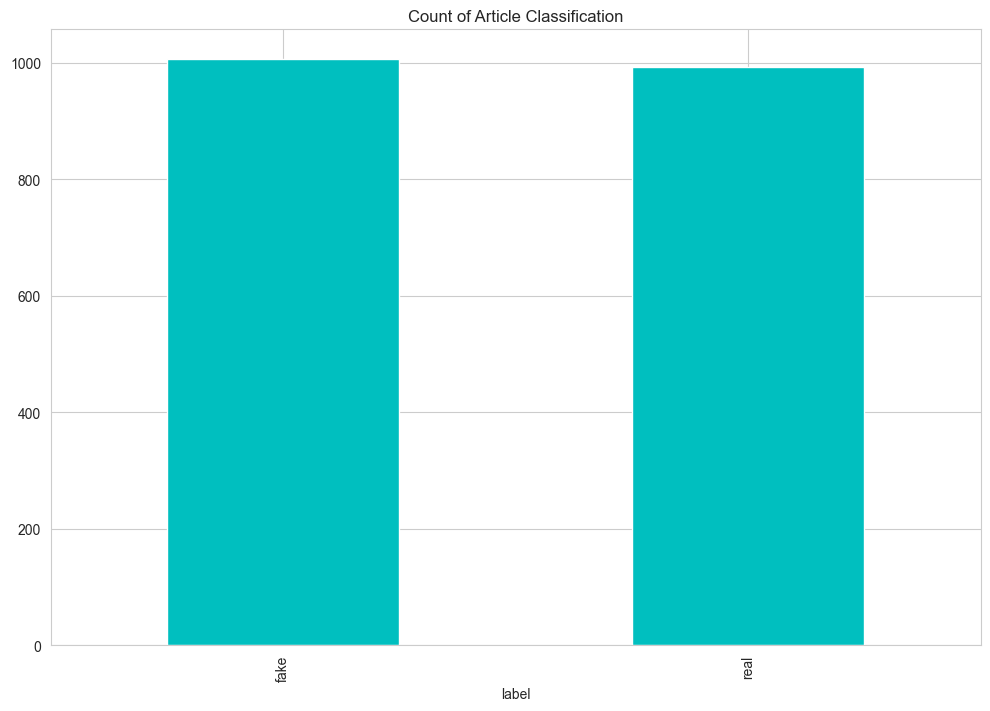

In [252]:
data['label'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title("Count of Article Classification")

In [253]:
print(data['label'].value_counts())

label
fake    1007
real     993
Name: count, dtype: int64


POS Tagging

In [254]:
nlp = spacy.load('en_core_web_sm')

In [255]:
fake_news = data[data['label'] == "fake"]
real_news = data[data['label'] == "real"]

In [256]:
fake_spacydocs = list(nlp.pipe(fake_news['text'].dropna().astype(str)))
real_spacydocs = list(nlp.pipe(real_news['text'].dropna().astype(str)))

In [257]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return[(i.text, i.ent_type_, i.pos_) for i in doc]

In [258]:
fake_tagsdf = []
columns = ["token", "ner_tag", "pos_tag"]

In [259]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

In [260]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [261]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,probably,,ADV
1,guess,,VERB
2,western,,ADJ
3,behind,,ADP
4,likely,,ADJ


In [262]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)


In [263]:
pos_counts_fake.head()


,token,pos_tag,counts
2913,whom,PRON,316
22,ability,NOUN,302
1791,or,CCONJ,301
1533,maybe,ADV,301
2541,structure,NOUN,298


In [264]:
pos_counts_fake[pos_counts_fake.pos_tag == 'NOUN'][:15]


,token,pos_tag,counts
22,ability,NOUN,302
2541,structure,NOUN,298
1611,moment,NOUN,297
1981,product,NOUN,293
2529,story,NOUN,292
2583,system,NOUN,289
509,collection,NOUN,288
946,fire,NOUN,287
1562,memory,NOUN,286
2712,tonight,NOUN,285


In [265]:
real_tagsdf = []
columns = ["token", "ner_tag", "pos_tag"]

In [266]:
for ix, doc in enumerate(real_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    real_tagsdf.append(tags)

In [267]:
real_tagsdf = pd.concat(real_tagsdf)


In [268]:
pos_counts_real = real_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)


In [269]:
pos_counts_real[pos_counts_real.pos_tag == 'NOUN'][:15]


,token,pos_tag,counts
53,activity,NOUN,302
1258,institution,NOUN,294
517,community,NOUN,290
1490,manager,NOUN,288
764,effort,NOUN,288
1445,loss,NOUN,287
454,child,NOUN,282
829,evidence,NOUN,280
2012,quality,NOUN,278
1088,guy,NOUN,277


Named Entities

In [270]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name= 'counts').sort_values(by='counts', ascending=False)

In [271]:
top_entities_real = real_tagsdf[real_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name= 'counts').sort_values(by='counts', ascending=False)

In [272]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6],
    "TIME": "purple",
    "ORDINAL": "orange"
}

[Text(0.5, 1.0, 'Most Common Named Entities in Fake News')]

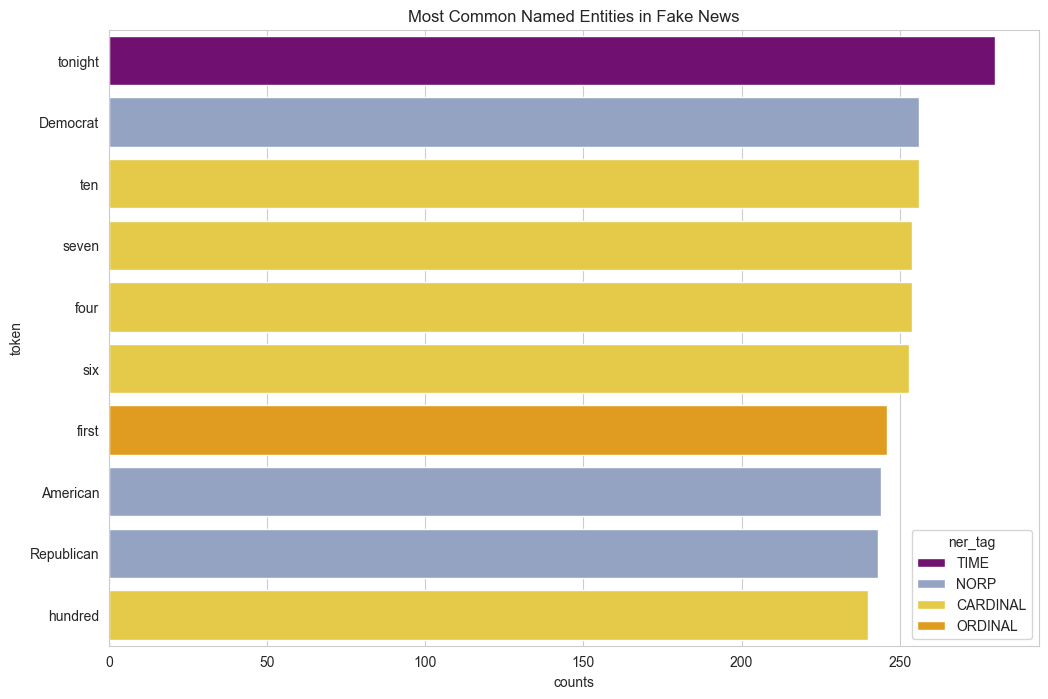

In [273]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False).set(title ="Most Common Named Entities in Fake News")

[Text(0.5, 1.0, 'Most Common Named Entities in Real News')]

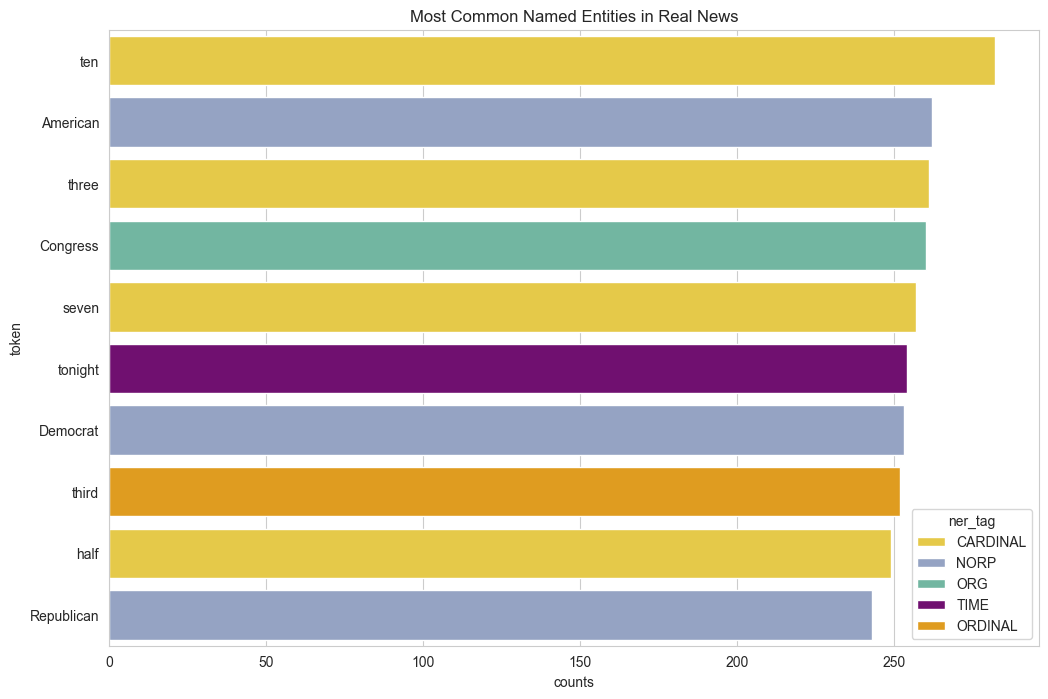

In [274]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_real[:10],
    orient = 'h',
    dodge = False).set(title ="Most Common Named Entities in Real News")

Text Pre-Processing

In [275]:
data.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [276]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s", "", x['text']), axis=1)

In [277]:
data['text_clean'] = data['text_clean'].str.lower()

In [278]:
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']), axis=1)

In [279]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [280]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in en_stopwords ]))

In [281]:
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis=1)

In [282]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [283]:
tokens_clean = sum(data['text_clean'], [])

In [284]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts())
unigrams = unigrams.reset_index(name='count')
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])
print(unigrams[:10])

          index  count      token
0         (mr,)    998         mr
1   (identify,)    592   identify
2     (method,)    586     method
3   (activity,)    583   activity
4        (ten,)    581        ten
5     (debate,)    579     debate
6      (ready,)    576      ready
7   (position,)    575   position
8  (structure,)    573  structure
9      (range,)    572      range


[Text(0.5, 1.0, 'Most Commmon Unigrams after Text Processing')]

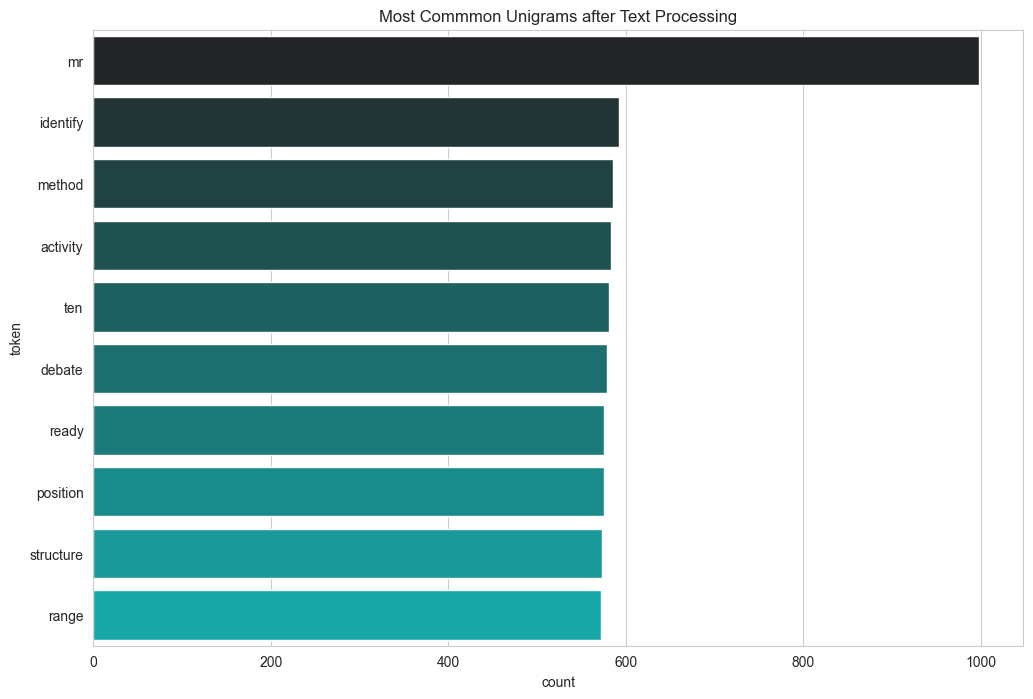

In [285]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(x="count",
            y="token",
            data=unigrams[:10],
            orient='h',
            palette='dark:#00bfbf',
            hue='token', legend=False).set(title ="Most Commmon Unigrams after Text Processing")

In [286]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts())
bigrams = bigrams.reset_index(name='count')
bigrams['token'] = bigrams['index'].apply(lambda x: x[0])
print(bigrams[:10])

                index  count     token
0      (worry, blood)      7     worry
1       (later, sure)      7     later
2      (message, tax)      6   message
3     (spend, ground)      6     spend
4  (usually, concern)      6   usually
5      (keep, animal)      6      keep
6   (agency, instead)      6    agency
7       (word, short)      6      word
8   (industry, share)      6  industry
9         (next, bit)      6      next


[Text(0.5, 1.0, 'Most Commmon Bigrams after Text Processing')]

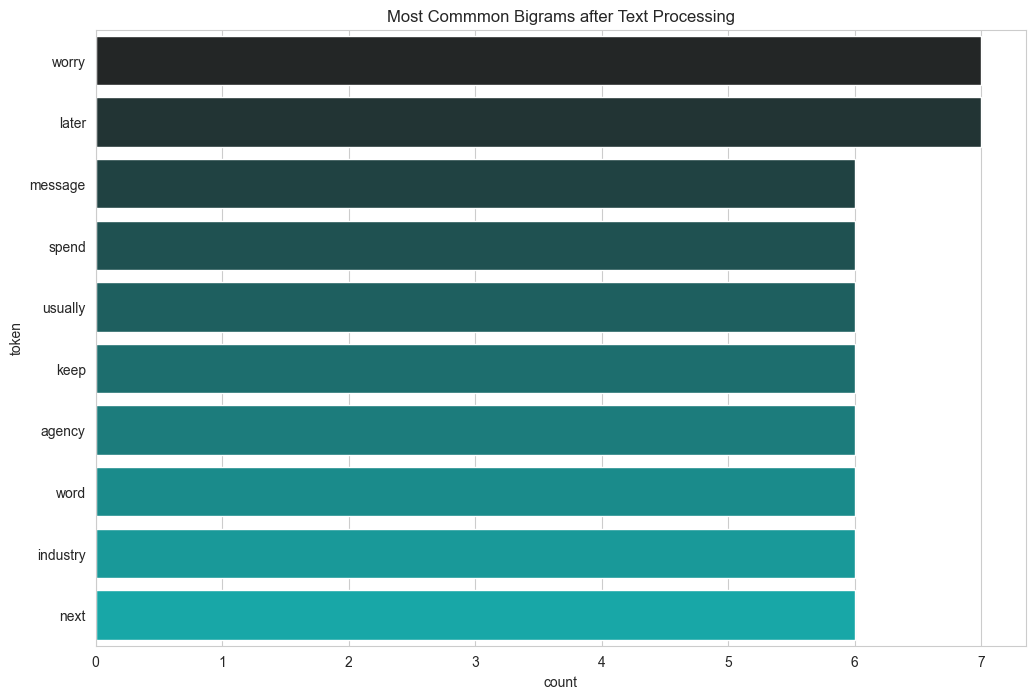

In [287]:
bigrams['token'] = bigrams['index'].apply(lambda x: x[0])

sns.barplot(x="count",
            y="token",
            data=bigrams[:10],
            orient='h',
            palette='dark:#00bfbf',
            hue='token', legend=False).set(title ="Most Commmon Bigrams after Text Processing")

Sentiment Analysis

In [288]:
vader_sentiment = SentimentIntensityAnalyzer()

In [289]:
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [290]:
data.head()


,title,text,date,source,author,category,label,text_clean,vader_sentiment_score
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,"[tax, development, store, agreement, lawyer, h...",0.9560
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,"[probably, guess, western, behind, likely, nex...",0.9943
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,"[identify, forward, present, success, risk, se...",0.6995
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,"[phone, item, yard, republican, safe, police, ...",0.9842
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,"[wonder, fact, difficult, course, forget, exac...",0.8020


In [291]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

In [292]:
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

In [293]:
data.head()

,title,text,date,source,author,category,label,text_clean,vader_sentiment_score,vader_sentiment_label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,"[tax, development, store, agreement, lawyer, h...",0.9560,positive
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,"[probably, guess, western, behind, likely, nex...",0.9943,positive
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,"[identify, forward, present, success, risk, se...",0.6995,positive
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,"[phone, item, yard, republican, safe, police, ...",0.9842,positive
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,"[wonder, fact, difficult, course, forget, exac...",0.8020,positive


<Axes: xlabel='vader_sentiment_label'>

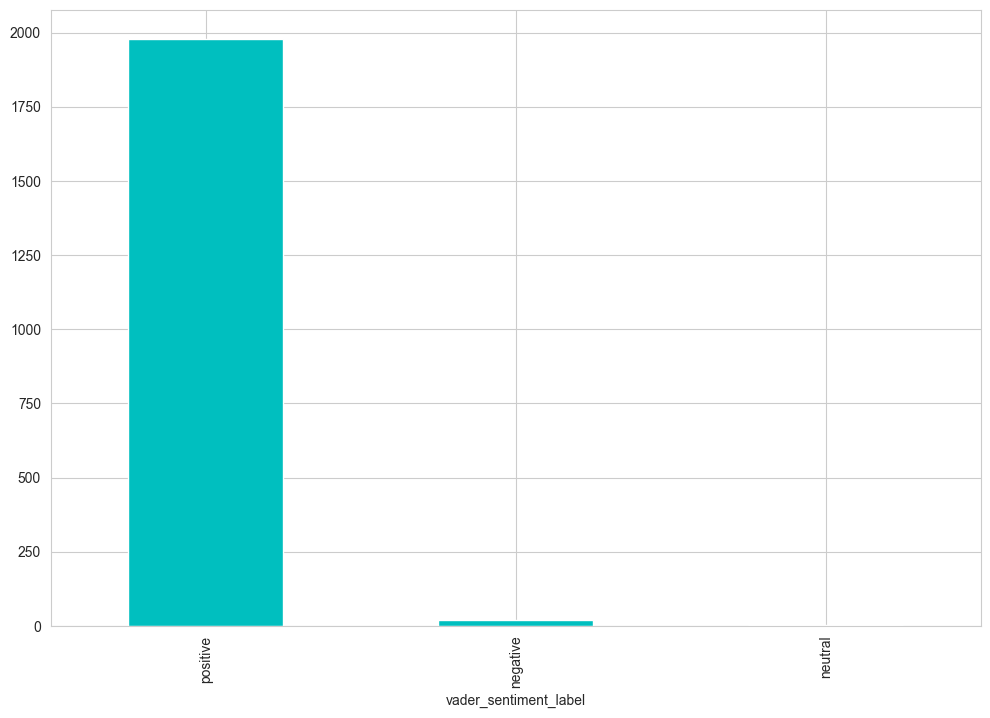

In [294]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/var/folders/15/r_c26kl94td48ryhxtt_kygr0000gn/T/ipykernel_80191/371416607.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

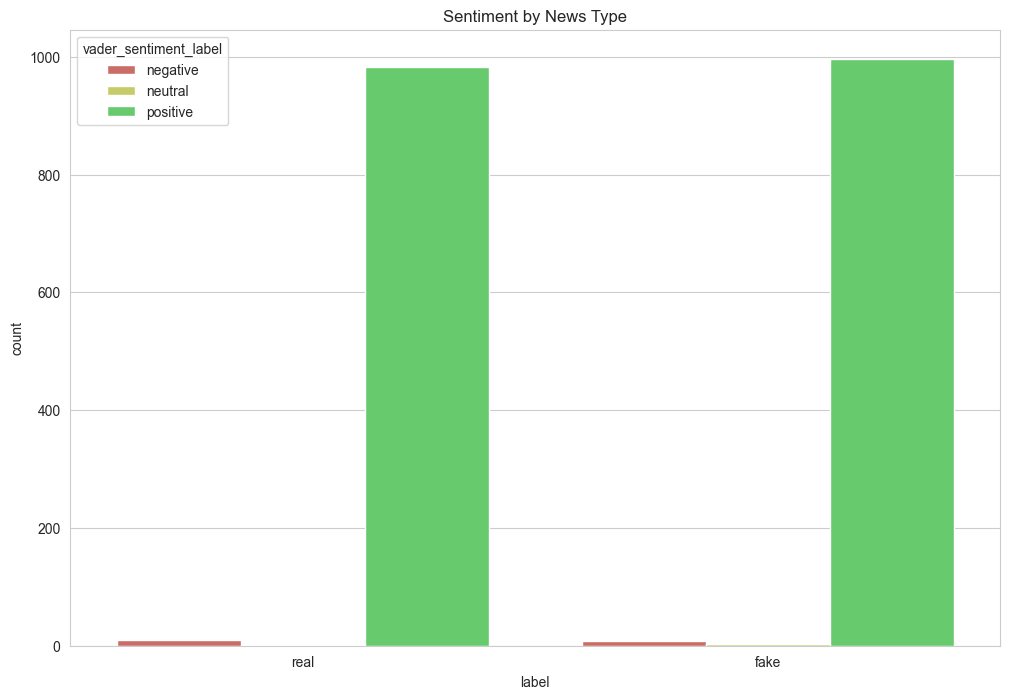

In [295]:
sns.countplot(
    x= 'label',
    hue='vader_sentiment_label',
    palette=sns.color_palette("hls"),
    data = data,
).set(title ="Sentiment by News Type")

Topic Modelling

In [296]:
fake_news_text = data[data["label"] == "fake"]['text_clean'].reset_index(drop=True)

In [297]:
dictionary_fake = corpora.Dictionary(fake_news_text)

In [298]:
doc_term_fake = (dictionary_fake.doc2bow(text) for text in fake_news_text)

In [299]:
coherence_values = []
model_list = []
min_topics = 2
max_topics = 11
doc_term_fake = list(doc_term_fake)

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(corpus=doc_term_fake, num_topics=num_topics_i, id2word=dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

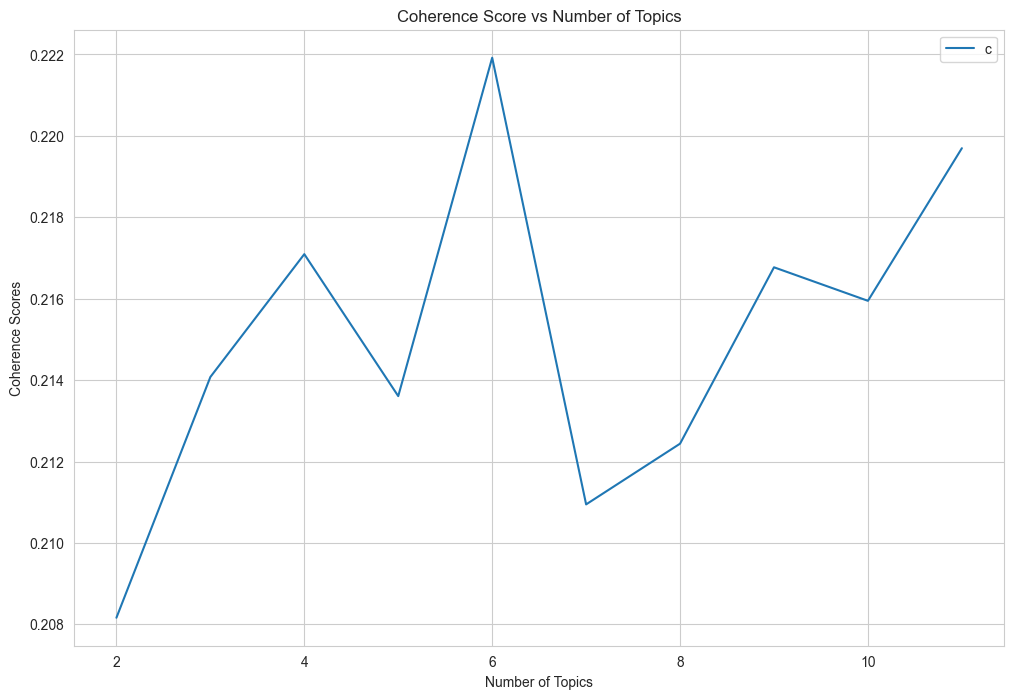

In [300]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.title("Coherence Score vs Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Scores")
plt.legend("coherence_values", loc='best')
plt.show()

In [301]:
num_topics_lda = 7
lda_model = gensim.models.LdaModel(corpus=doc_term_fake,id2word=dictionary_fake, num_topics=num_topics_lda)

In [302]:
lda_model.print_topics(num_topics=num_topics_lda, num_words=10)


[(0,
  '0.002*"mr" + 0.002*"treat" + 0.002*"involve" + 0.002*"fire" + 0.002*"conference" + 0.002*"act" + 0.002*"international" + 0.002*"industry" + 0.002*"answer" + 0.002*"trip"'),
 (1,
  '0.003*"mr" + 0.002*"change" + 0.002*"process" + 0.002*"shoulder" + 0.002*"information" + 0.002*"call" + 0.002*"maybe" + 0.002*"west" + 0.002*"ability" + 0.002*"wear"'),
 (2,
  '0.002*"center" + 0.002*"mr" + 0.002*"seven" + 0.002*"moment" + 0.002*"range" + 0.002*"meet" + 0.002*"rich" + 0.002*"must" + 0.002*"leave" + 0.002*"high"'),
 (3,
  '0.002*"training" + 0.002*"thank" + 0.002*"property" + 0.002*"company" + 0.002*"dark" + 0.002*"general" + 0.002*"section" + 0.002*"size" + 0.002*"story" + 0.002*"national"'),
 (4,
  '0.002*"mr" + 0.002*"choose" + 0.002*"avoid" + 0.002*"magazine" + 0.002*"ability" + 0.002*"common" + 0.002*"effect" + 0.002*"activity" + 0.002*"music" + 0.002*"building"'),
 (5,
  '0.002*"mr" + 0.002*"necessary" + 0.002*"wind" + 0.002*"collection" + 0.002*"minute" + 0.002*"apply" + 0.002*

In [303]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus = doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [304]:
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word=dictionary)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence = 'c_v')
        coherence_values.append(coherence_model.get_coherence())

    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.title("LSI Topic Model Coherence Score vs Number of Topics")
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Scores")
    plt.legend("coherence_values", loc='best')
    plt.show()

In [305]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

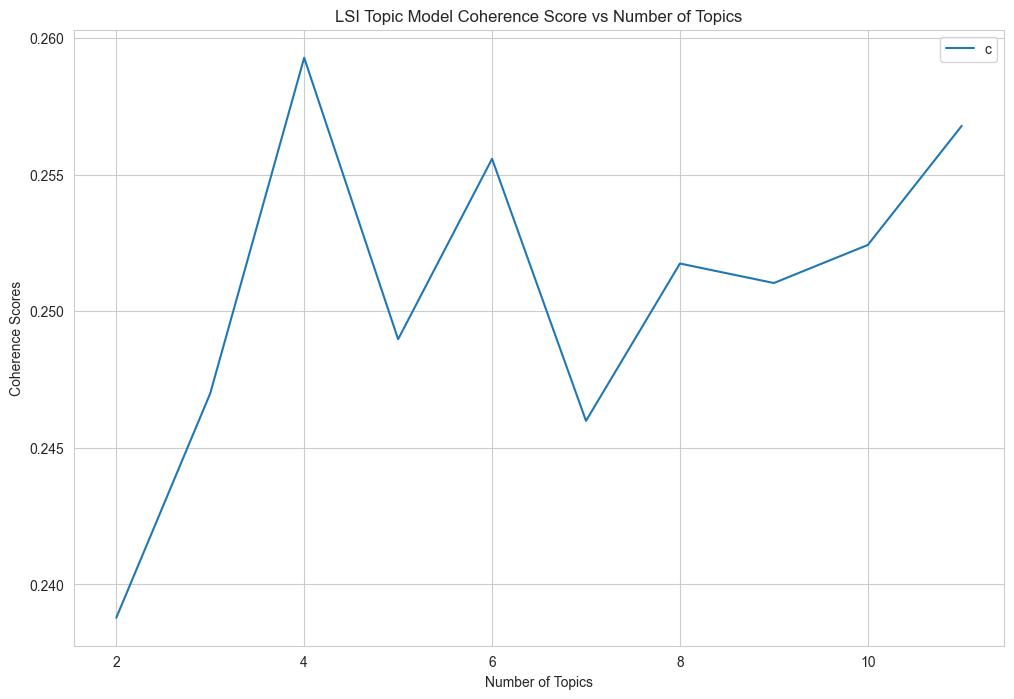

In [306]:
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [307]:
lsa_model = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=7)

In [308]:
lsa_model.print_topics()


[(0,
  '0.041*"mr" + 0.037*"form" + 0.037*"fire" + 0.037*"ready" + 0.037*"structure" + 0.037*"watch" + 0.036*"thank" + 0.036*"board" + 0.036*"position" + 0.036*"ability"'),
 (1,
  '-0.117*"school" + -0.098*"democratic" + -0.097*"glass" + 0.092*"couple" + 0.091*"political" + -0.091*"bit" + 0.090*"hand" + -0.089*"clear" + 0.088*"yes" + 0.085*"send"'),
 (2,
  '-0.118*"also" + 0.114*"writer" + -0.113*"particularly" + -0.105*"event" + 0.099*"edge" + -0.088*"total" + -0.087*"image" + 0.087*"word" + -0.085*"sure" + -0.083*"goal"'),
 (3,
  '-0.126*"detail" + -0.121*"marriage" + -0.102*"ball" + 0.096*"pressure" + 0.095*"life" + -0.090*"rather" + 0.089*"attack" + 0.087*"measure" + 0.085*"year" + 0.083*"world"'),
 (4,
  '-0.115*"heart" + -0.106*"occur" + -0.101*"society" + 0.099*"administration" + 0.098*"hospital" + -0.091*"maybe" + 0.091*"home" + -0.088*"today" + 0.088*"others" + 0.086*"series"'),
 (5,
  '-0.176*"among" + 0.113*"today" + 0.108*"order" + 0.102*"high" + -0.102*"house" + -0.101*"st

Creating Classification Model

In [309]:
data.head()

,title,text,date,source,author,category,label,text_clean,vader_sentiment_score,vader_sentiment_label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,"[tax, development, store, agreement, lawyer, h...",0.9560,positive
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,"[probably, guess, western, behind, likely, nex...",0.9943,positive
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,"[identify, forward, present, success, risk, se...",0.6995,positive
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,"[phone, item, yard, republican, safe, police, ...",0.9842,positive
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,"[wonder, fact, difficult, course, forget, exac...",0.8020,positive


In [310]:
x = [','.join(map(str,l )) for l in data['text_clean']]


In [311]:
y = data[('label')]


In [312]:
countvec = CountVectorizer()

In [313]:
countvec_fit = countvec.fit_transform(x)


In [314]:
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [315]:
x_train, x_test, y_train, y_test = train_test_split(bag_of_words, y, test_size=0.3)

In [316]:
lr = LogisticRegression(random_state=0).fit(x_train, y_train)

In [317]:
y_pred_lr = lr.predict(x_test)

In [318]:
accuracy_score(y_pred_lr, y_test)

0.49

In [319]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

        fake       0.49      0.46      0.47       303
        real       0.49      0.53      0.50       297

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.49      0.49      0.49       600



In [320]:
svm = SGDClassifier().fit(x_train, y_train)


In [321]:
y_pred_svm = svm.predict(x_test)


In [322]:
accuracy_score(y_pred_svm, y_test)


0.49166666666666664

In [323]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

        fake       0.50      0.45      0.47       303
        real       0.49      0.53      0.51       297

    accuracy                           0.49       600
   macro avg       0.49      0.49      0.49       600
weighted avg       0.49      0.49      0.49       600

